# EDA dan cleaning dataset Pokemon TCG

Notebook ini menganalisis seluruh metadata CSV dan audit gambar lokal dari manifest downloader. Tidak ada request HTTP dari notebook.

## 1. Memuat dataset dan menentukan lokasi file

Cell berikut memuat metadata kartu dari CSV, menentukan lokasi gambar lokal dan manifest, serta menampilkan contoh data.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if not (root / 'backend' / 'dataset').exists():
    root = root.parent.parent

dataset_dir = root / 'backend' / 'dataset'
csv_path = dataset_dir / 'pokemon_cards_dataset.csv'
json_path = dataset_dir / 'pokemon_cards_dataset.json'
image_dir = dataset_dir / 'pokemon-cards-dataset'
manifest_path = image_dir / 'image_manifest.csv'
clean_csv_path = dataset_dir / 'pokemon_cards_dataset_clean.csv'
clean_json_path = dataset_dir / 'pokemon_cards_dataset_clean.json'

df = pd.read_csv(csv_path)
print(f'Metadata: {len(df):,} baris, {len(df.columns)} kolom')
print(f'Folder gambar: {image_dir}')
print(f'Manifest tersedia: {manifest_path.exists()}')
display(df.head())

Metadata: 19,979 baris, 10 kolom
Folder gambar: c:\Gas-Belajar\Proyek-Analitika-Data-Sistem-Cerdas\backend\dataset\pokemon-cards-dataset
Manifest tersedia: True


,card_id,name,number,rarity,types,set.name,set.release_date,images.large,prices.cardmarket_trend,prices.tcgplayer_variants.holofoil.market
0,hgss4-1,Aggron,1,Rare Holo,Metal,HS—Triumphant,2010/11/03,https://images.pokemontcg.io/hgss4/1_hires.png,3.64,9.80
1,xy5-1,Weedle,1,Common,Grass,Primal Clash,2015/02/04,https://images.pokemontcg.io/xy5/1_hires.png,0.12,NaN
2,pl1-1,Ampharos,1,Rare Holo,Lightning,Platinum,2009/02/11,https://images.pokemontcg.io/pl1/1_hires.png,5.78,32.44
3,dp3-1,Ampharos,1,Rare Holo,Lightning,Secret Wonders,2007/11/01,https://images.pokemontcg.io/dp3/1_hires.png,6.06,42.56
4,det1-1,Bulbasaur,1,Common,Grass,Detective Pikachu,2019/04/05,https://images.pokemontcg.io/det1/1_hires.png,0.63,1.13


## 2. Memeriksa kualitas metadata

Cell ini menghitung nilai kosong, jumlah nilai unik, duplikasi `card_id`, dan jumlah kartu unik.

In [2]:
missing_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
    'unique_count': df.nunique(dropna=True),
}).sort_values('missing_count', ascending=False)
display(missing_summary)
print(f"Duplicate card_id: {df['card_id'].duplicated().sum():,}")
print(f"Unique card_id: {df['card_id'].nunique():,}")

,dtype,missing_count,missing_percent,unique_count
prices.tcgplayer_variants.holofoil.market,float64,12842,64.28,3498
types,object,3079,15.41,35
prices.cardmarket_trend,float64,1393,6.97,3202
rarity,object,303,1.52,38
card_id,object,0,0.00,19979
name,object,0,0.00,4381
number,object,0,0.00,1724
set.name,object,0,0.00,175
set.release_date,object,0,0.00,156
images.large,object,0,0.00,19979


Duplicate card_id: 0
Unique card_id: 19,979


## 3. Mengeksplorasi distribusi kartu dan harga

Cell ini menampilkan distribusi rarity dan tipe kartu, rentang tanggal rilis, serta ringkasan ketersediaan data harga.

<Axes: title={'center': 'Top rarity'}, ylabel='rarity'>

<Axes: title={'center': 'Top tipe kartu'}, ylabel='types'>

Kolom 'supertype' tidak tersedia pada CSV; distribusi supertype dilewati.
Rentang rilis: 1999-01-09 sampai 2026-07-17


,field,available,missing,coverage_percent,min,median,mean,max
0,prices.cardmarket_trend,18586,1393,93.03,0.00,0.70,12.612460,6312.26
1,prices.tcgplayer_variants.holofoil.market,7137,12842,35.72,0.04,7.26,44.280666,4500.00


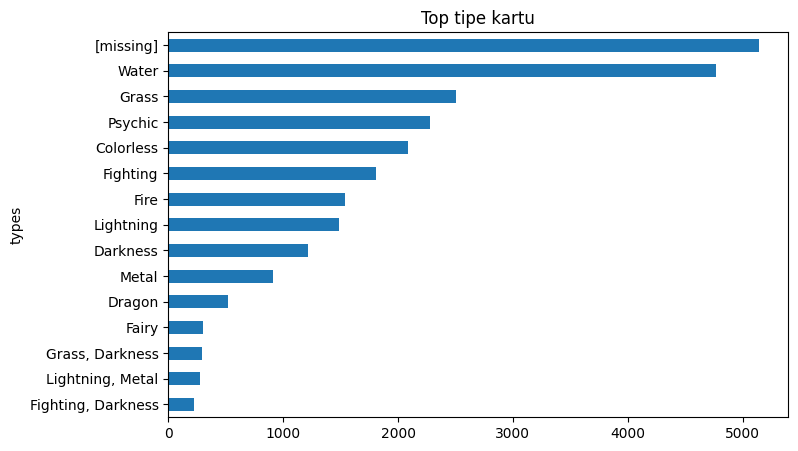

In [3]:
def plot_top(column, title, limit=15):
    counts = df[column].fillna('[missing]').value_counts().head(limit)
    return counts.sort_values().plot(kind='barh', title=title, figsize=(8, 5))

display(plot_top('rarity', 'Top rarity'))
display(plot_top('types', 'Top tipe kartu'))
if 'supertype' in df.columns:
    display(df['supertype'].fillna('[missing]').value_counts().to_frame('count'))
else:
    print("Kolom 'supertype' tidak tersedia pada CSV; distribusi supertype dilewati.")

release_dates = pd.to_datetime(df['set.release_date'], format='%Y/%m/%d', errors='coerce')
print('Rentang rilis:', release_dates.min().date(), 'sampai', release_dates.max().date())
price_rows = []
for column in ['prices.cardmarket_trend', 'prices.tcgplayer_variants.holofoil.market']:
    values = pd.to_numeric(df[column], errors='coerce')
    price_rows.append({
        'field': column,
        'available': int(values.notna().sum()),
        'missing': int(values.isna().sum()),
        'coverage_percent': round(values.notna().mean() * 100, 2),
        'min': values.min(),
        'median': values.median(),
        'mean': values.mean(),
        'max': values.max(),
    })
display(pd.DataFrame(price_rows))

## 4. Mengaudit gambar yang sudah diunduh

Cell ini membaca manifest, memeriksa keberadaan file lokal, ukuran file, resolusi minimum, dan status validitas gambar. Cell ini tidak mengunduh gambar.

In [4]:
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path, dtype=str).fillna('')
    manifest['width'] = pd.to_numeric(manifest['width'], errors='coerce')
    manifest['height'] = pd.to_numeric(manifest['height'], errors='coerce')
    manifest['file_size'] = pd.to_numeric(manifest['file_size'], errors='coerce')
    manifest['local_exists'] = manifest['local_path'].map(lambda value: Path(value).exists())
    manifest['image_valid'] = (
        manifest['status'].eq('downloaded')
        & manifest['local_exists']
        & manifest['width'].ge(100)
        & manifest['height'].ge(100)
        & manifest['file_size'].gt(0)
    )
    display(manifest['status'].value_counts().to_frame('count'))
    display(manifest[['width', 'height', 'file_size']].describe())
    print(f"Gambar valid lokal: {manifest['image_valid'].sum():,}/{len(manifest):,}")
else:
    manifest = pd.DataFrame(columns=['card_id', 'image_valid'])
    print('Manifest belum ada. Jalankan downloader terlebih dahulu.')

,count
status,
downloaded,300


,width,height,file_size
count,300.00000,300.000000,3.000000e+02
mean,663.44000,919.740000,8.051965e+05
std,73.38217,107.750606,2.284944e+05
min,400.00000,550.000000,4.766850e+05
25%,600.00000,825.000000,6.375440e+05
50%,600.00000,835.000000,8.100705e+05
75%,734.00000,1024.000000,8.957682e+05
max,734.00000,1024.000000,1.944299e+06


Gambar valid lokal: 300/300


## 5. Membuat dataset clean

Cell terakhir mempertahankan kartu yang memiliki gambar lokal valid, lalu menulis ulang CSV dan JSON clean. Kekosongan harga atau metadata tidak menjadi alasan untuk menghapus kartu.

In [ ]:
# Missing harga atau metadata tidak otomatis menghapus kartu.
valid_ids = set(manifest.loc[manifest['image_valid'], 'card_id'])
clean_df = df[df['card_id'].astype(str).isin(valid_ids)].copy()
clean_df.to_csv(clean_csv_path, index=False)

if json_path.exists():
    with json_path.open(encoding='utf-8') as handle:
        json_records = json.load(handle)
    clean_records = [
        record for record in json_records
        if str(record.get('card_id')) in valid_ids
    ]
    with clean_json_path.open('w', encoding='utf-8') as handle:
        json.dump(clean_records, handle, ensure_ascii=False, indent=2)
else:
    clean_records = []

print(f'Baris metadata awal: {len(df):,}')
print(f'Baris clean berbasis gambar lokal: {len(clean_df):,}')
print(f'Drop: {len(df) - len(clean_df):,}')
print(f'CSV clean: {clean_csv_path}')
print(f'JSON clean: {clean_json_path} ({len(clean_records):,} record)')